#Student Information

*   **Student ID:** 20521641
*   **Full Name:** Nguyễn Thị Ngọc Nga






#Connect Drive & Unzip Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/CS116_PythonForML/

/content/drive/MyDrive/CS116_PythonForML


In [ ]:
!unzip /content/drive/MyDrive/CS116_PythonForML/test.csv.zip

Archive:  /content/drive/MyDrive/CS116_PythonForML/test.csv.zip
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
!unzip /content/drive/MyDrive/CS116_PythonForML/train.csv.zip

Archive:  /content/drive/MyDrive/CS116_PythonForML/train.csv.zip
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


#Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from imblearn.over_sampling import ADASYN,RandomOverSampler
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
%matplotlib inline

#Load Data & EDA

In [ ]:
pd.set_option('display.max_columns',35)
train_path = r'train.csv'
test_path = r'test.csv'
train_df = pd.read_csv(train_path, low_memory=False)
test_df = pd.read_csv(test_path)

In [ ]:
test_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,9,13.27,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,4,12.27,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,5,11.27,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,4,6,1,Credit-Builder Loan,3,1,5.42,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [ ]:
train_df.shape

(100000, 28)

In [ ]:
train_df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [ ]:
train_df.drop(['ID','Name','SSN'],axis=1,inplace=True) #drop cac cot co data trong

Monthly_Inhand_Salary      0.15002
Type_of_Loan               0.11408
Num_of_Delayed_Payment     0.07002
Num_Credit_Inquiries       0.01965
Credit_History_Age         0.09030
Amount_invested_monthly    0.04479
Monthly_Balance            0.01200
dtype: float64


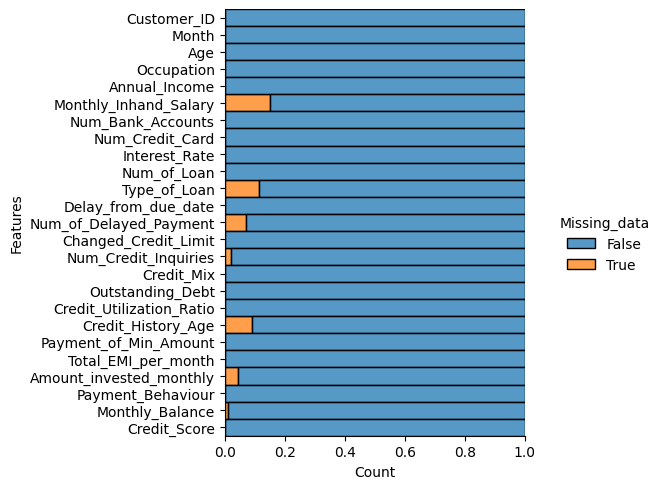

In [ ]:
#kiem tra ti le NaN
def na_ratio_plot(df=train_df):

    sns.displot(df.isna().melt(value_name='Missing_data',var_name='Features')\
                ,y='Features',hue='Missing_data',multiple='fill',aspect=9/8)

print(train_df.isna().mean()[train_df.isna().mean()>0])
na_ratio_plot()

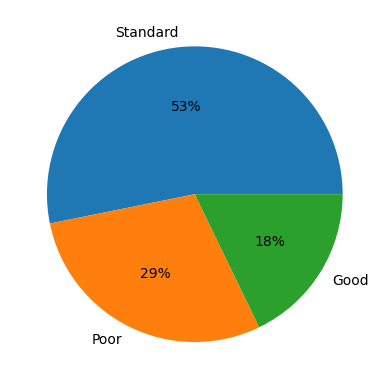

In [ ]:
def target_ratio(df=train_df,target='Credit_Score'):

    if not target:
        plt.pie(df.value_counts(),labels=df.value_counts()
                .index,autopct='%.0f%%')

    else:
        plt.pie(df[target].value_counts(),labels=df[target]
                .value_counts().index,autopct='%.0f%%')

target_ratio()

In [ ]:
train_df.drop_duplicates(inplace=True)

In [ ]:
mix_type_num_col = ['Age', 'Annual_Income', 'Num_of_Loan',
                    'Num_of_Delayed_Payment','Changed_Credit_Limit',
                    'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

def set_numeric_columns(features,df=None):

    df[features]=df[features].apply(lambda x: x.replace('_','',regex=True) )
    df[features]=df[features].apply(lambda x: x.str.strip())
    df[features]=df[features].apply(lambda x: x.replace('',np.nan))
# Convert numeric columns dtypes.
    df[features[1:]]=df[features[1:]].astype('float32')
    df[features[0]]=df[features[0]].astype('int32')

set_numeric_columns(mix_type_num_col,df=train_df)

In [ ]:
train_df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,92998.000000,97909.000000,98035.000000,100000.000000,100000.000000,100000.000000,95521.000000,9.880000e+04
mean,110.649700,1.764157e+05,4194.170850,17.091280,22.47443,72.466040,3.009960,21.068780,30.923342,10.389025,27.754251,1426.220337,32.285173,1403.118217,637.413025,-3.036437e+22
std,686.244717,1.429618e+06,3183.686167,117.404834,129.05741,466.422621,62.647877,14.860104,226.031891,6.789496,193.177339,1155.129028,5.116875,8306.041270,2043.319336,inf
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.00000,1.000000,-100.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,0.000000,0.000000,-3.333333e+26
25%,24.000000,1.945750e+04,1625.568229,3.000000,4.00000,8.000000,1.000000,10.000000,9.000000,5.320000,3.000000,566.072510,28.052567,30.306660,74.534004,2.700922e+02
50%,33.000000,3.757861e+04,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,14.000000,9.400000,6.000000,1166.154968,32.305784,69.249473,135.925674,3.367192e+02
75%,42.000000,7.279092e+04,5957.448333,7.000000,7.00000,20.000000,5.000000,28.000000,18.000000,14.870000,9.000000,1945.962555,36.496663,161.224249,265.731720,4.702202e+02
max,8698.000000,2.419806e+07,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,4397.000000,36.970001,2597.000000,4998.069824,50.000000,82331.000000,10000.000000,1.602041e+03


In [ ]:
def replace_invalid_2_nan(df):

    _= {'Occupation': '_'*7, 'Credit_Mix':'_','Payment_Behaviour':'!@9#%8'}
    for x in _.items():
        df[x[0]].replace(x[1],np.nan,inplace=True)

replace_invalid_2_nan(train_df)

In [ ]:
def convert_str_num(column,indicator,magnitude,df=train_df):
    i=indicator
    m=magnitude
    # set as a float for flexibility of the function.
    _=df[column].apply(lambda x: float(x.split(' ')[i[0]])*m[0]+
                                 float(x.split(' ')[i[1]])*m[1]
                                if type(x)==str else x)
    return _

In [ ]:
train_df.Credit_History_Age=convert_str_num('Credit_History_Age',[0,3],[12,1])

In [ ]:
train_df.Credit_History_Age.head(4)

0    265.0
1      NaN
2    267.0
3    268.0
Name: Credit_History_Age, dtype: float64

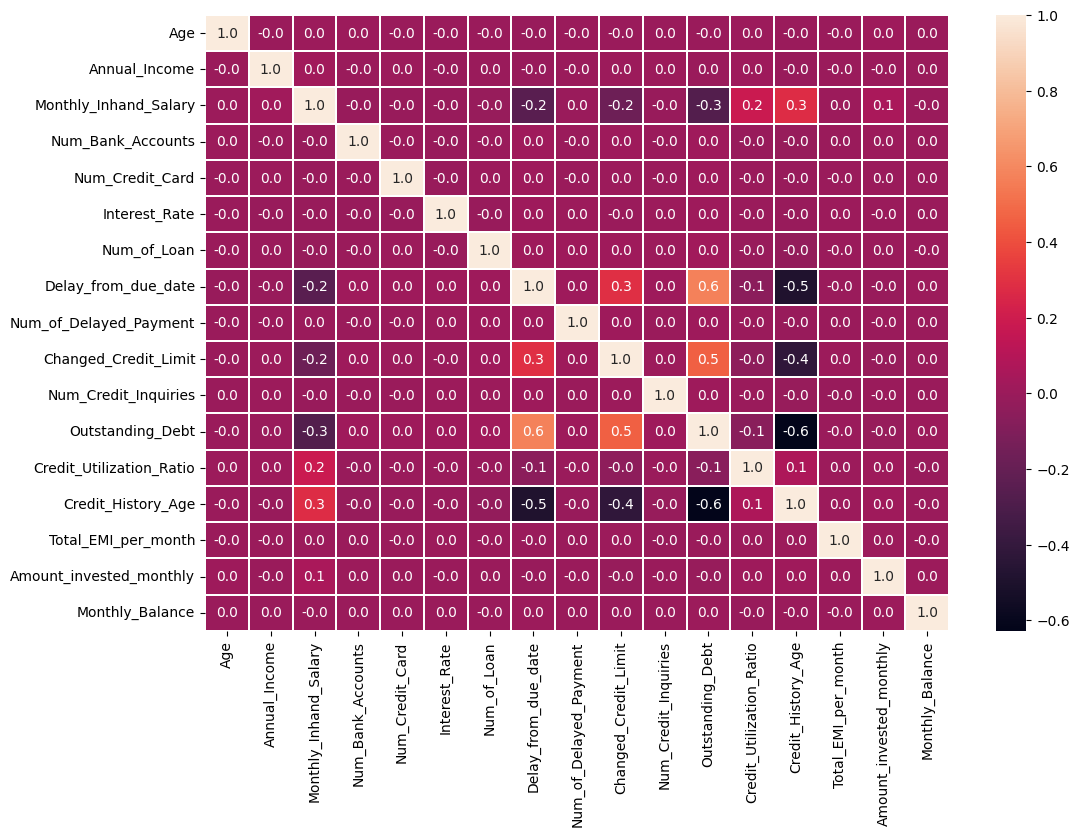

In [ ]:
def correlation_plot(df=train_df):
    plt.figure(figsize=[12,8])
    sns.heatmap(df.select_dtypes(exclude='object')
                .dropna().corr(),annot=True,
                fmt='.1f',linewidth=.2)

correlation_plot()

In [ ]:
def plots_by_categ(feature1,plot_type='hist',
                   feature2='Credit_Score',
                   df=train_df,multi_class=True,bins=30):

    if df[feature1].nunique()<30:
        bins=df[feature1].nunique()

    else:
        pass

    if multi_class:
        _=df[feature2].unique().tolist()
        col=len(_)

        if df[feature1].dtype!='O':
            col+=1

        fig,axes=plt.subplots(1,col,sharey='none',figsize=[14,5])
    else:
        pass

    if plot_type.lower()=='scatter':

        if multi_class:
            fig.suptitle(f'{feature2}')

            for i,v in enumerate(_):
                sns.scatterplot(y=(df[feature1][df[feature2]==v]).dropna(),
                                x=(df[feature1][df[feature2]==v]).dropna().index,
                                ax=axes[i])
                axes[i].set_title(f'{v}\n{feature2}')
        else:
            plt.figure(figsize=[4,3])
            sns.scatterplot(x=df[feature1],y=df[feature2])
    else:
        if multi_class:
            for i,value in enumerate(_):

                if df[feature1].dtype!='O':
                    i+=1

                    if i==1:
                        sns.kdeplot(data=df[[feature1,feature2]],
                                    x=feature1,hue=feature2,
                                    ax=axes[0])

                sns.histplot((df[feature1][df[feature2]==value]).dropna(),
                             bins=bins,ax=axes[i],kde=True)

                axes[i].set_title(f'{value} {feature2}')
        else:
            plt.figure(figsize=[4,4])
            sns.set_style("whitegrid", {'axes.grid' : False})
            sns.histplot(data=df[[feature1,feature2]],
                         x=feature1,bins=bins,hue=feature2)

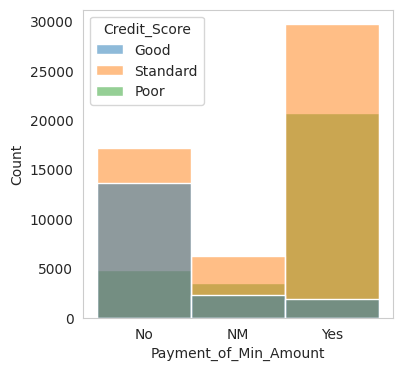

In [ ]:
plots_by_categ('Payment_of_Min_Amount',multi_class=False)

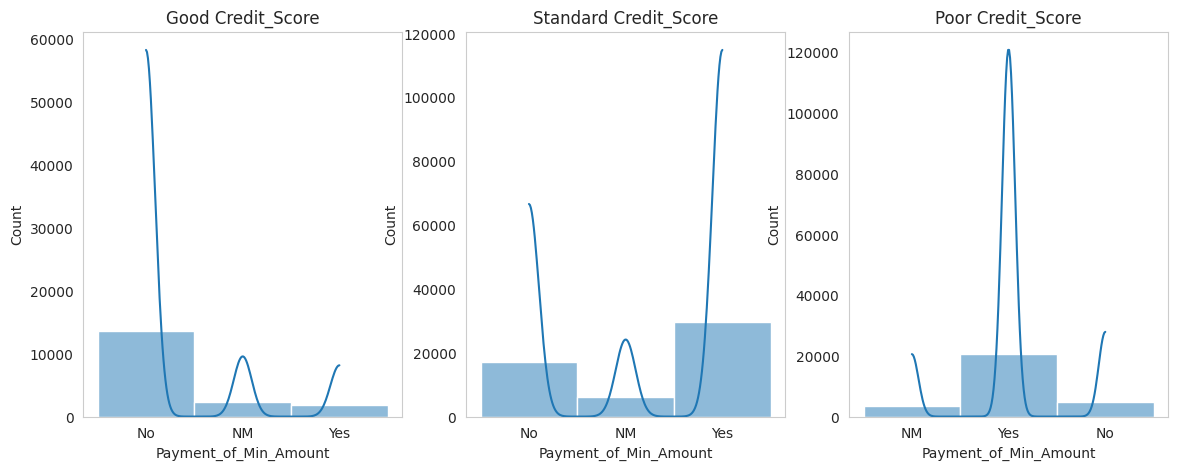

In [ ]:
plots_by_categ('Payment_of_Min_Amount')

#Load Clean Data

In [ ]:
%cd /content/drive/MyDrive/[CS116] Lập trình Python cho ML

/content/drive/.shortcut-targets-by-id/1lEcWUmlO6Ezr-effHzBr4bErLfSGwoym/[CS116] Lập trình Python cho ML


In [ ]:
df = pd.read_csv("./Files/cleaned_credit_score.csv")
X = df.loc[:, df.columns != 'Credit_Score'].to_numpy()
y = df['Credit_Score'].to_numpy()

#Import Libraries Again

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                            precision_recall_fscore_support,
                            f1_score, recall_score,
                            precision_score,
                            confusion_matrix,
                            ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import scipy.stats as stats
import re
import seaborn as sns

#Traning & Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
model = HistGradientBoostingClassifier(verbose=3)

In [ ]:
model.fit(X_train, y_train)

Binning 0.019 GB of training data: 0.256 s
Binning 0.002 GB of validation data: 0.012 s
Fitting gradient boosted rounds:
[1/100] 3 trees, 93 leaves (31 on avg), max depth = 9, train loss: 0.90290, val loss: 0.90187, in 0.071s
[2/100] 3 trees, 93 leaves (31 on avg), max depth = 9, train loss: 0.83549, val loss: 0.83405, in 0.072s
[3/100] 3 trees, 93 leaves (31 on avg), max depth = 10, train loss: 0.78685, val loss: 0.78500, in 0.070s
[4/100] 3 trees, 93 leaves (31 on avg), max depth = 11, train loss: 0.75101, val loss: 0.74871, in 0.069s
[5/100] 3 trees, 93 leaves (31 on avg), max depth = 10, train loss: 0.72387, val loss: 0.72149, in 0.068s
[6/100] 3 trees, 93 leaves (31 on avg), max depth = 10, train loss: 0.70288, val loss: 0.70063, in 0.070s
[7/100] 3 trees, 93 leaves (31 on avg), max depth = 11, train loss: 0.68643, val loss: 0.68418, in 0.074s
[8/100] 3 trees, 93 leaves (31 on avg), max depth = 9, train loss: 0.67303, val loss: 0.67079, in 0.069s
[9/100] 3 trees, 93 leaves (31 on 

HistGradientBoostingClassifier(verbose=3)

In [ ]:
model.score(X_test, y_test)

0.76655

#Fine Tuning

In [ ]:
param_grid = {
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 0.0002, 0.002, 0.02, 0.2 , 0.0005, 0.005, 0.05, 0.5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'l2_regularization': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    'max_leaf_nodes':[20, 25, 30, 35, 40, 45],
    'min_samples_leaf':[10, 15, 20, 25 ,30],
    'early_stopping': [True, False],
    'warm_start': [True, False]
}

In [ ]:
clf = RandomizedSearchCV(model, param_grid, n_iter=50 , verbose=3)
search = clf.fit(X_train, y_train)

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
[90/100] 3 trees, 23 leaves (7 on avg), max depth = 3, train loss: 0.78165, val loss: 0.78242, in 0.041s
[91/100] 3 trees, 24 leaves (8 on avg), max depth = 3, train loss: 0.78033, val loss: 0.78111, in 0.045s
[92/100] 3 trees, 23 leaves (7 on avg), max depth = 3, train loss: 0.77900, val loss: 0.77979, in 0.044s
[93/100] 3 trees, 23 leaves (7 on avg), max depth = 3, train loss: 0.77771, val loss: 0.77852, in 0.053s
[94/100] 3 trees, 23 leaves (7 on avg), max depth = 3, train loss: 0.77643, val loss: 0.77723, in 0.046s
[95/100] 3 trees, 24 leaves (8 on avg), max depth = 3, train loss: 0.77517, val loss: 0.77600, in 0.045s
[96/100] 3 trees, 23 leaves (7 on avg), max depth = 3, train loss: 0.77391, val loss: 0.77475, in 0.046s
[97/100] 3 trees, 23 leaves (7 on avg), max depth = 3, train loss: 0.77267, val loss: 0.77351, in 0.044s
[98/100] 3 trees, 23 leaves (7 on avg), max depth = 3, train loss: 0.77146, val loss: 0.77232, in 0.048

In [ ]:
# convert array into dataframe
cv_results = pd.DataFrame(search.cv_results_)

# save the dataframe as a csv file
cv_results.to_csv("./Files/RandomSearch_CV_HGBC.csv")


In [ ]:
cv_results = pd.read_csv("./Files/RandomSearch_CV_HGBC.csv")

In [ ]:
keys = ['param_'+key for key in param_grid.keys()]
keys.append('mean_test_score')
cv_results.sort_values(by=['rank_test_score']).head()[keys]

,param_learning_rate,param_max_depth,param_l2_regularization,param_max_leaf_nodes,param_min_samples_leaf,param_early_stopping,param_warm_start,mean_test_score
33,0.2,9,0.1,45,15,True,True,0.786250
14,0.2,8,0.0,40,10,True,True,0.782375
23,0.2,7,0.1,30,20,False,False,0.776275
39,0.5,6,0.1,20,15,True,True,0.772850
44,0.1,10,0.5,35,30,False,True,0.761537


In [ ]:
search.best_params_

{'warm_start': True,
 'min_samples_leaf': 15,
 'max_leaf_nodes': 45,
 'max_depth': 9,
 'learning_rate': 0.2,
 'l2_regularization': 0.1,
 'early_stopping': True}

In [ ]:
print(f"Best score after RandomSearchCV: {search.best_score_}")

Best score after RandomSearchCV: 0.78625


#Evaluation

##Compare Default Model & Tuned Model

In [ ]:
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2)

clf = HistGradientBoostingClassifier(warm_start= True,
 min_samples_leaf= 30,
 max_leaf_nodes= 30,
 max_depth= 9,
 learning_rate= 0.2,
 l2_regularization= 0.3,
 early_stopping= False)
clf_default = HistGradientBoostingClassifier(random_state=0)

clf.fit(X_train, y_train)
clf_default.fit(X_train, y_train)

print("Accuracy test on tuned model: ", clf.score(X_test, y_test))
print("Accuracy test on default model: ", clf_default.score(X_test, y_test))

X shape:  (100000, 33)
y shape:  (100000,)
Accuracy test on tuned model:  0.78265
Accuracy test on default model:  0.76325


In [ ]:
target_names = ['Good', 'Poor', 'Standard']

y_pred = clf_default.predict(X_test)
print(" " * 24, end="")
print("DEFAULT MODEL")
print(classification_report(y_test, y_pred, target_names=target_names))
print(f"F1 {f1_score(y_pred, y_test, average='macro')}")
print(f"Recall {recall_score(y_pred, y_test, average='macro')}")
print(f"Precision {precision_score(y_pred, y_test, average='macro')}")

print("=" * 50, end='\n\n')

y_pred = clf.predict(X_test)
print(" " * 24, end="")
print("TUNED MODEL")
print(classification_report(y_test, y_pred, target_names=target_names))
print(f"F1 {f1_score(y_pred, y_test, average='macro')}")
print(f"Recall {recall_score(y_pred, y_test, average='macro')}")
print(f"Precision {precision_score(y_pred, y_test, average='macro')}")

                        DEFAULT MODEL
              precision    recall  f1-score   support

        Good       0.68      0.75      0.72      3627
        Poor       0.77      0.73      0.75      5781
    Standard       0.79      0.79      0.79     10592

    accuracy                           0.76     20000
   macro avg       0.75      0.76      0.75     20000
weighted avg       0.76      0.76      0.76     20000

F1 0.7505468661338776
Recall 0.7473081765497875
Precision 0.7551842236446866

                        TUNED MODEL
              precision    recall  f1-score   support

        Good       0.73      0.76      0.75      3627
        Poor       0.77      0.77      0.77      5781
    Standard       0.81      0.80      0.80     10592

    accuracy                           0.78     20000
   macro avg       0.77      0.78      0.77     20000
weighted avg       0.78      0.78      0.78     20000

F1 0.7728067004774887
Recall 0.7690820170111022
Precision 0.7768792200489631


##K-Fold Validation

In [ ]:
kf = KFold(n_splits=10, shuffle=True)
acc = []
f1_macro = []
recall_macro = []
precision_macro = []
metrics = []
confusion_matrices = np.zeros((3,3))
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    clf.fit(X[train_index], y[train_index])
    y_pred = clf.predict(X[test_index])
    print(classification_report(y[test_index], y_pred, target_names=target_names))
    metrics.append(precision_recall_fscore_support(y[test_index], y_pred))
    print()
    acc.append(clf.score(X[test_index], y[test_index]))
    f1_macro.append(f1_score(y[test_index], y_pred, average="macro"))
    recall_macro.append(recall_score(y[test_index], y_pred, average="macro"))
    precision_macro.append(precision_score(y[test_index], y_pred, average="macro"))
    confusion_matrices = confusion_matrices + confusion_matrix(y[test_index], y_pred)

print("Mean accuray:", np.mean(acc))

Fold 0:
              precision    recall  f1-score   support

        Good       0.78      0.84      0.81      1820
        Poor       0.82      0.83      0.82      2934
    Standard       0.86      0.83      0.84      5246

    accuracy                           0.83     10000
   macro avg       0.82      0.83      0.82     10000
weighted avg       0.83      0.83      0.83     10000


Fold 1:
              precision    recall  f1-score   support

        Good       0.78      0.82      0.80      1770
        Poor       0.81      0.83      0.82      3011
    Standard       0.85      0.83      0.84      5219

    accuracy                           0.83     10000
   macro avg       0.81      0.82      0.82     10000
weighted avg       0.83      0.83      0.83     10000


Fold 2:
              precision    recall  f1-score   support

        Good       0.80      0.83      0.81      1738
        Poor       0.81      0.83      0.82      2868
    Standard       0.86      0.84      0.85      

##Visualize Result

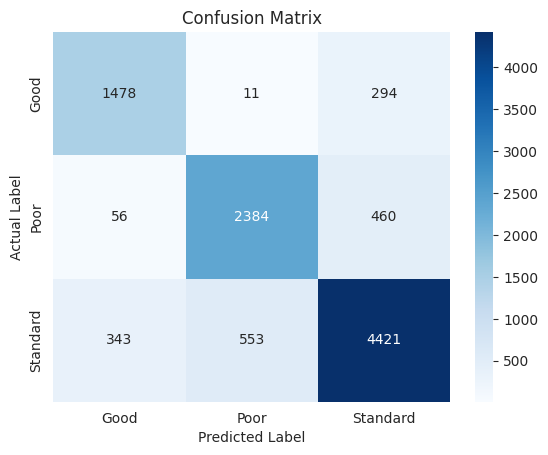

In [ ]:
# Create labels for the confusion matrix
labels = ['Good', 'Poor', 'Standard']

# Create a heatmap using seaborn
sns.heatmap(np.round(confusion_matrices / 10).astype(np.int64), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)

# Set plot title and axes labels
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# Display the plot
plt.show()

In [ ]:
print(f"Mean Accuracy : {np.mean(acc)}")
print(f"Average macro F1 : {np.mean(f1_macro)}")
print(f"Average macro Recall : {np.mean(recall_macro)}")
print(f"Average macro Precision : {np.mean(precision_macro)}")

Mean Accuracy : 0.8282299999999999
Average macro F1 : 0.8217841039768758
Average macro Recall : 0.8274434766703352
Average macro Precision : 0.8166798214048484


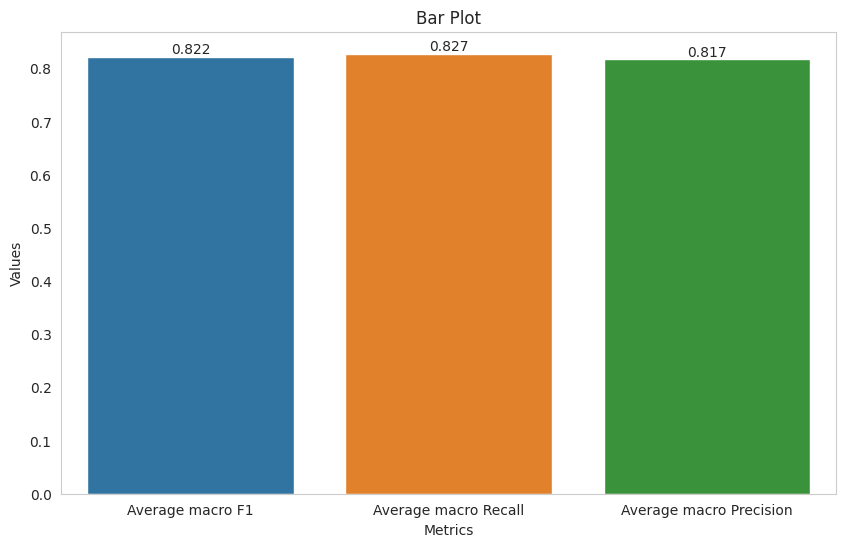

In [ ]:
# Sample data
categories = ['Average macro F1', 'Average macro Recall', 'Average macro Precision']
values = [np.mean(f1_macro), np.mean(recall_macro), np.mean(precision_macro)]

# Set the figure size
plt.figure(figsize=(10, 6))

# Create bar plot
sns.barplot(x=categories, y=values)

# Add numbers on top of the bars
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 3)), ha='center', va='bottom')

# Set plot title and axes labels
plt.title('Bar Plot')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Display the plot
plt.show()


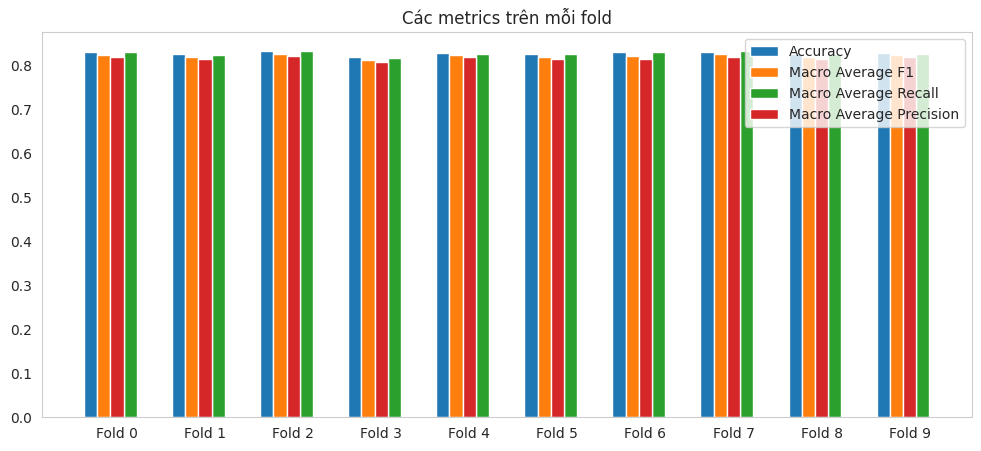

In [ ]:
plt.figure(figsize=(12,5))
X_ticks = ["Fold " + str(i) for i in range(10)]
X_axis = np.arange(len(X_ticks))
plt.bar(X_axis - 0.3, acc, 0.15, label="Accuracy", tick_label=X_ticks)
plt.bar(X_axis - 0.15, f1_macro, 0.15, label="Macro Average F1", tick_label=X_ticks)
plt.bar(X_axis + 0.15, recall_macro, 0.15, label="Macro Average Recall", tick_label=X_ticks)
plt.bar(X_axis, precision_macro, 0.15, label="Macro Average Precision", tick_label=X_ticks)
plt.title("Các metrics trên mỗi fold")
plt.legend()
plt.show()

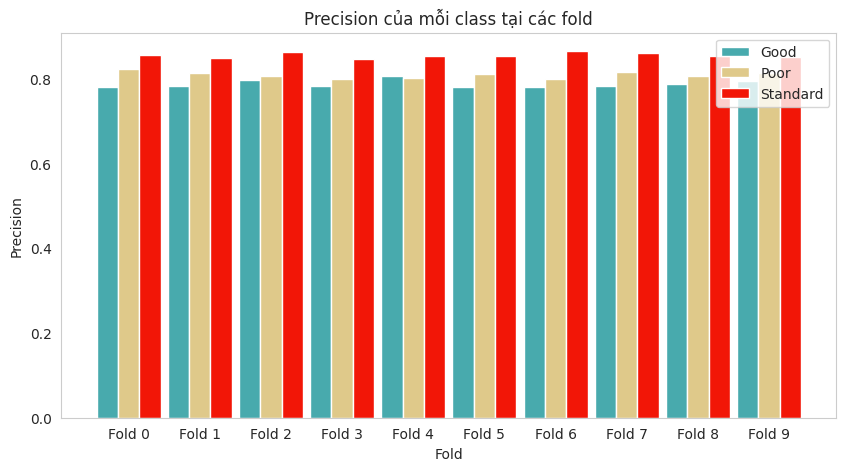

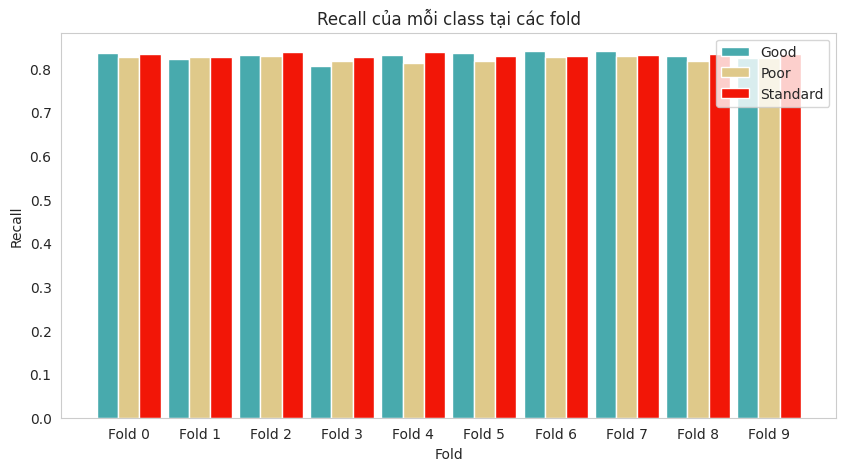

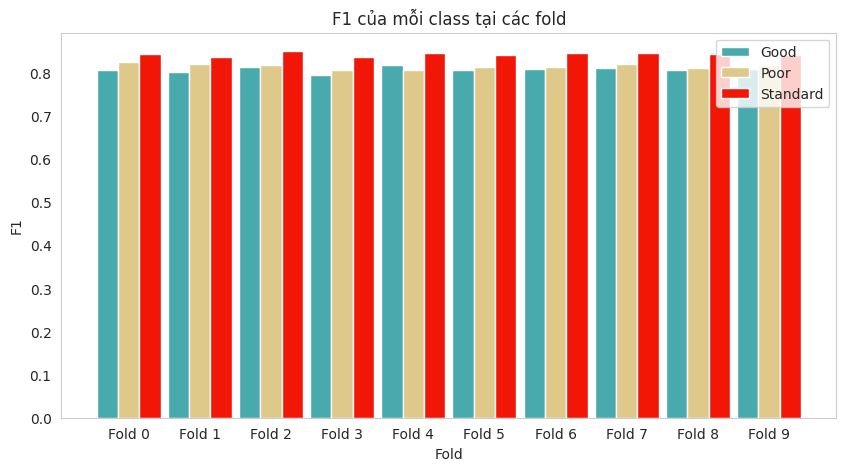

In [ ]:
metrics_dict = {
    "Precision": [],
    "Recall" : [],
    "F1": []
}

for i in range(10):
  metrics_dict["Precision"].append(metrics[i][0])
  metrics_dict["Recall"].append(metrics[i][1])
  metrics_dict["F1"].append(metrics[i][2])

metrics_dict["Precision"] = np.vstack(metrics_dict["Precision"])
metrics_dict["Recall"] = np.vstack(metrics_dict["Recall"])
metrics_dict["F1"] = np.vstack(metrics_dict["F1"])

for metric, values in metrics_dict.items():
  plt.figure(figsize=(10,5))
  plt.bar(X_axis - 0.2, values[:, 0], 0.3,
          label="Good", color="#48AAAD")
  plt.bar(X_axis + 0.1, values[:, 1], 0.3,
          label="Poor", tick_label=X_ticks, color="#DFC98A")
  plt.bar(X_axis + 0.4, values[:, 2], 0.3,
          label="Standard", color="#f21607")

  plt.title(f"{metric} của mỗi class tại các fold")
  plt.xlabel("Fold")
  plt.ylabel(f"{metric}")

  plt.legend()
  plt.show()